In [1]:
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, precision_score, recall_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc,
)
import nibabel as nib
from sklearn.neighbors import LocalOutlierFactor

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib import rcParams


from deap import base, creator, tools, algorithms  # evolutionary search

import matplotlib.pyplot as plt
import seaborn as sns  # optional, only if you actually use its styling/helpers
from tqdm import tqdm

# Local/project modules — avoid wildcards if you can, e.g., import only what's used
from run_models import train, test
from models import *  # ideally replace with explicit imports: e.g., from models import SomeModelClass
from ConvolutionalAE import ConvolutionalAE_upd

from utils import *
### CONV AE
from sklearn.model_selection import train_test_split
# from skimage.measure import find_contours


/home/jurgen/.local/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


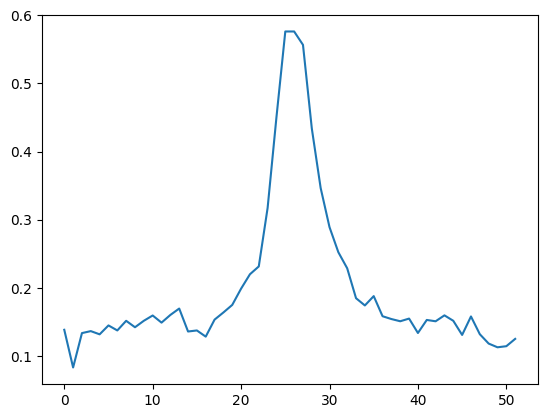

In [ ]:

#rat_data_postGAD = np.load('data/RatTumorData_updatedMasks.npz')
rat_data_postGAD = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
Rat_Z_Spectras = 1- rat_data_postGAD['zspec']
Rat_Healthy_Idx = rat_data_postGAD['voxelInds_healthy']
Rat_Tumor_Idx = rat_data_postGAD['voxelInds_tumor']
rat_healthy_all = Rat_Z_Spectras[Rat_Healthy_Idx]
rat_tumor_all = Rat_Z_Spectras[Rat_Tumor_Idx]

plt.plot(rat_healthy_all[0])


In [3]:

# Load data
rat_data_HEALTHY_TRAIN = np.load('data/ratData_healthy_all4_rats.npz')
#rat_data_HEALTHY_TRAIN = np.load('data/RatTumorData_postGd_fit_new (2).npz')
Rat_Z_Spectras_HEALTHY_TRAIN = 1- rat_data_HEALTHY_TRAIN['zspec']
#Rat_Z_Spectras_HEALTHY_TRAIN = 1- rat_data_HEALTHY_TRAIN['fits']
Rat_Healthy_Idx__HEALTHY_TRAIN = rat_data_HEALTHY_TRAIN['voxelInds_healthy']
#Rat_Healthy_Idx__HEALTHY_TRAIN = rat_data_HEALTHY_TRAIN['roimasks']
rat_healthy_all_HEALTHY_TRAIN = Rat_Z_Spectras_HEALTHY_TRAIN[Rat_Healthy_Idx__HEALTHY_TRAIN]



In [4]:
Rat_Z_Spectras_HEALTHY_TRAIN.shape

(147456, 52)

In [5]:
rat_data_HEALTHY_TRAIN.keys()

KeysView(NpzFile 'data/ratData_healthy_all4_rats.npz' with keys: zspec, voxelInds_healthy, image_shape, imageShape)

(147456, 52)


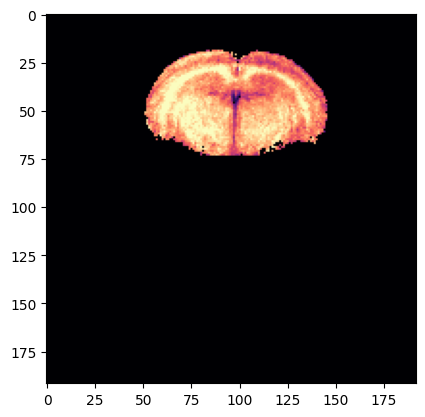

In [6]:
# --- Reconstruct Original Image ---
Healthy_Voxel_img_train = Rat_Z_Spectras_HEALTHY_TRAIN
inds = Rat_Healthy_Idx__HEALTHY_TRAIN
tempImg = np.zeros((4,192,192,52))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 52)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_HEALTHY_TRAIN     # Assign values at indexed positions
Healthy_Voxel_img_train = tempImg_flat.reshape((4,192,192,52))  # Reshape back
Healthy_Voxel_img_train.shape
Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 52)
print(Train_Image_Set.shape)
Train_Image_Set_indx = np.where(Train_Image_Set.sum(axis=1) >0)
train_extracted = Train_Image_Set[Train_Image_Set_indx]
train_extracted.shape

plt.imshow(Healthy_Voxel_img_train[3,:,:,0], vmin = 0, vmax=0.35, cmap='magma')



In [7]:
train_extracted.shape

(16548, 52)

In [8]:
print(Train_Image_Set.shape)

(147456, 52)


In [9]:
# --- Reconstruct Original Image ---
Tumor_Voxel_img =1- Rat_Z_Spectras
inds = Rat_Tumor_Idx
tempImg = np.zeros(rat_data_postGAD['imageShape']) # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 52)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_tumor_all # Assign values at indexed positions
Tumor_Voxel_img = tempImg_flat.reshape(rat_data_postGAD['imageShape'])  # Reshape back
Tumor_Voxel_img.shape

(3, 192, 192, 52)

(3, 192, 192, 52)


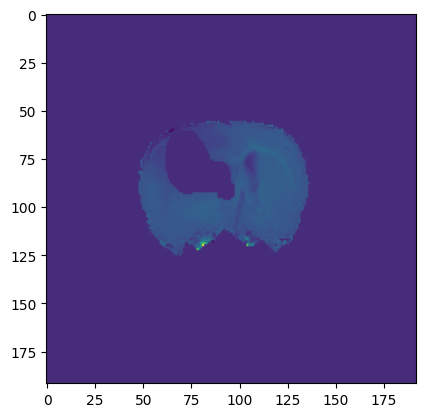

In [10]:
# --- Reconstruct Original Image ---
Healthy_Voxel_img_postGAD = Rat_Z_Spectras
inds = Rat_Healthy_Idx
tempImg = np.zeros(rat_data_postGAD['imageShape'])  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 52)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all   # Assign values at indexed positions
Healthy_Voxel_img_postGAD = tempImg_flat.reshape(rat_data_postGAD['imageShape'])  # Reshape back
print(Healthy_Voxel_img_postGAD.shape)
plt.imshow(Healthy_Voxel_img_postGAD[2,:,:,0])


In [11]:


Test_Image_Set = Tumor_Voxel_img.reshape(-1, 52)
print(Test_Image_Set.shape)
Test_Image_Set_indx = np.where(Test_Image_Set.sum(axis=1) > 0)[0]
Healthy_test = Healthy_Voxel_img_postGAD.reshape(-1, 52)
Healthy_test_idx = np.where(Healthy_test.sum(axis=1) > 0)[0]
test_idx =np.concatenate([Test_Image_Set_indx,Healthy_test_idx])
print(Test_Image_Set_indx.shape)




(110592, 52)
(1495,)


(3, 192, 192, 52)


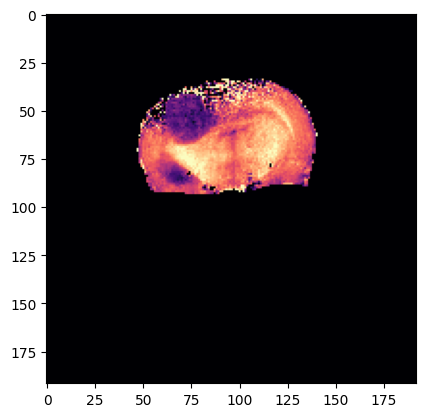

In [12]:



test_extracted= np.concatenate([Rat_Z_Spectras[Test_Image_Set_indx],Rat_Z_Spectras[Healthy_test_idx]], axis=0)
test_extracted.shape
Test_img =Rat_Z_Spectras
inds = test_idx
tempImg = np.zeros(rat_data_postGAD['imageShape'])  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 52)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  test_extracted      # Assign values at indexed positions
Test_img = tempImg_flat.reshape(rat_data_postGAD['imageShape'])  # Reshape back
Test_img.shape
plt.imshow(Test_img[1, :, :, 0], vmin=0, vmax=0.4, cmap='magma')
print(Test_img.shape)




In [13]:

Healthy_Voxel_img_all   = Healthy_Voxel_img_train
Healthy_Voxel_img_train = Healthy_Voxel_img_all[:3]        
Healthy_Voxel_img_val   = Healthy_Voxel_img_all[-1]       

Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 52)
Val_Image_Set   = Healthy_Voxel_img_val.reshape(-1, 52)

train_extracted = Train_Image_Set
val_extracted   = Val_Image_Set
print("train_extracted:", train_extracted.shape)
print("val_extracted:  ", val_extracted.shape)


train_extracted: (110592, 52)
val_extracted:   (36864, 52)


In [14]:

rat_train_data   = train_extracted
rat_val_data     = val_extracted
rat_test_data    = test_extracted

rat_train_labels = np.ones(len(rat_train_data), dtype=int)   # all healthy
rat_val_labels   = np.ones(len(rat_val_data),   dtype=int)   # all healthy
rat_test_labels  = np.concatenate(
    [np.ones(len(Test_Image_Set_indx)), np.zeros(len(Healthy_test_idx))],
    axis=0
).astype(int)

print("Train data shape:", rat_train_data.shape)
print("Val   data shape:", rat_val_data.shape)
print("Test  data shape:", rat_test_data.shape)
print("Train label counts:", np.unique(rat_train_labels, return_counts=True))
print("Val   label counts:", np.unique(rat_val_labels,   return_counts=True))
print("Test  label counts:", np.unique(rat_test_labels,  return_counts=True))


Train data shape: (110592, 52)
Val   data shape: (36864, 52)
Test  data shape: (14250, 52)
Train label counts: (array([1]), array([110592]))
Val   label counts: (array([1]), array([36864]))
Test  label counts: (array([0, 1]), array([12755,  1495]))


In [15]:

# ---- Torch tensors & loaders ----
X_train = torch.from_numpy(rat_train_data).float().unsqueeze(1)  # (N,1,52)
X_val   = torch.from_numpy(rat_val_data).float().unsqueeze(1)
X_test  = torch.from_numpy(rat_test_data).float().unsqueeze(1)

print("new shape: ", X_train.shape, X_val.shape, X_test.shape)


new shape:  torch.Size([110592, 1, 52]) torch.Size([36864, 1, 52]) torch.Size([14250, 1, 52])


In [16]:

train_ds = TensorDataset(X_train)
val_ds   = TensorDataset(X_val)
test_ds  = TensorDataset(X_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)
y_train, y_val, y_test = rat_train_labels, rat_val_labels, rat_test_labels


In [17]:
# --- Split the pooled TEST voxels into (a) 2-rat TEST and (b) 1-rat Unhealthy-VAL ---
VAL_RAT_ID = 2  # hold out rat index 0/1/2 for the pathological validation set

R, H, W, O = rat_data_postGAD['imageShape']  # e.g., (3,192,192,52)
block = H * W
start = VAL_RAT_ID * block
end   = start + block


In [18]:

# Masks to select flat indices belonging to the held-out rat
tumor_mask_val   = (Test_Image_Set_indx >= start)   & (Test_Image_Set_indx < end)
healthy_mask_val = (Healthy_test_idx   >= start)    & (Healthy_test_idx   < end)


In [19]:

# Indices for the held-out rat (unhealthy validation) vs remaining two rats (actual test)
tumor_idx_val    = Test_Image_Set_indx[tumor_mask_val]
healthy_idx_val  = Healthy_test_idx[healthy_mask_val]
tumor_idx_test   = Test_Image_Set_indx[~tumor_mask_val]
healthy_idx_test = Healthy_test_idx[~healthy_mask_val]


In [20]:

# Build arrays (pull from same flattened source you used earlier)
val_unhealthy_extracted = np.vstack([
    Rat_Z_Spectras[tumor_idx_val],
    Rat_Z_Spectras[healthy_idx_val]
])  # (N_val_unhealthy, 52)

rat_test_extracted = np.vstack([
    Rat_Z_Spectras[tumor_idx_test],
    Rat_Z_Spectras[healthy_idx_test]
])  # (N_test, 52)

# Labels: tumor=1, healthy=0
y_val_unhealthy = np.concatenate([
    np.ones(len(tumor_idx_val),    dtype=int),
    np.zeros(len(healthy_idx_val), dtype=int)
])
y_test = np.concatenate([
    np.ones(len(tumor_idx_test),    dtype=int),
    np.zeros(len(healthy_idx_test), dtype=int)
])

print("Held-out Unhealthy VAL:", val_unhealthy_extracted.shape, y_val_unhealthy.shape)
print("Two-rat TEST:          ", rat_test_extracted.shape,      y_test.shape)


Held-out Unhealthy VAL: (4930, 52) (4930,)
Two-rat TEST:           (9320, 52) (9320,)


In [21]:

# ---- Replace ONLY the test set with the two-rat split; keep train/healthy-val the same ----
rat_test_data   = rat_test_extracted
rat_test_labels = y_test

# Tensors/loaders (keep your existing X_train/X_val/train_loader/val_loader unchanged)
X_test  = torch.from_numpy(rat_test_data).float().unsqueeze(1)
test_ds = TensorDataset(X_test)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

# NEW: loader for the held-out pathological validation rat
X_val_unhealthy = torch.from_numpy(val_unhealthy_extracted).float().unsqueeze(1)
val_unhealthy_ds = TensorDataset(X_val_unhealthy)
val_unhealthy_loader = DataLoader(val_unhealthy_ds, batch_size=128, shuffle=False)

# order matches val_unhealthy_extracted = [tumor rows; healthy rows]
y_val_unhealthy = np.concatenate([
    np.ones(len(tumor_idx_val),    dtype=int),  # 1 = tumor
    np.zeros(len(healthy_idx_val), dtype=int)   # 0 = healthy
])

print("y_val_unhealthy shape:", y_val_unhealthy.shape)
print("counts:", np.unique(y_val_unhealthy, return_counts=True))
print("first 10 labels:", y_val_unhealthy[:10])


y_val_unhealthy shape: (4930,)
counts: (array([0, 1]), array([4083,  847]))
first 10 labels: [1 1 1 1 1 1 1 1 1 1]


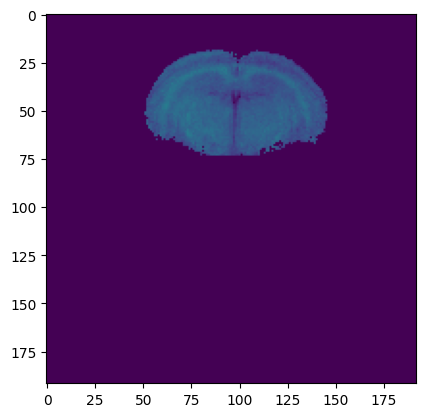

In [22]:
plt.imshow(Healthy_Voxel_img_val[:,:,0], vmin = 0, vmax =1)

## Load Model

In [25]:
cae_model = ConvolutionalAE_upd(seq_len=52)
checkpoint_cae = 'Checkpoints/4RATS_Optimal_final.pth'
cae_model.load_state_dict(torch.load(checkpoint_cae))


<All keys matched successfully>

In [26]:
cae_test_results = test(cae_model,test_loader)
# cae_val_results = test(cae_model,val_loader)
cae_val_unhealthy_rec = test(cae_model, val_unhealthy_loader)

# ###################################################################################################################################################

### Set Val Threshold

### Generate ROC

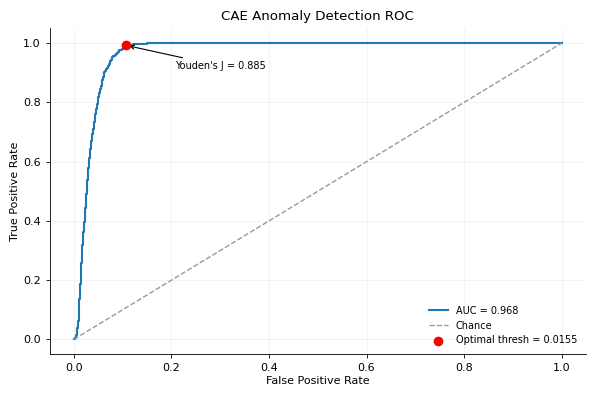

In [27]:
recon = X_test.squeeze(1)  # torch tensor, shape (N, features)
recon_errors =   np.mean((recon.numpy() - cae_test_results) ** 2, axis=1)
y_true = rat_test_labels  # binary array
metrics = roc_analysis(y_true, recon_errors, pos_label=1)
fig, ax = plot_roc_clean(metrics, save_path="figure_roc_cae.pdf")

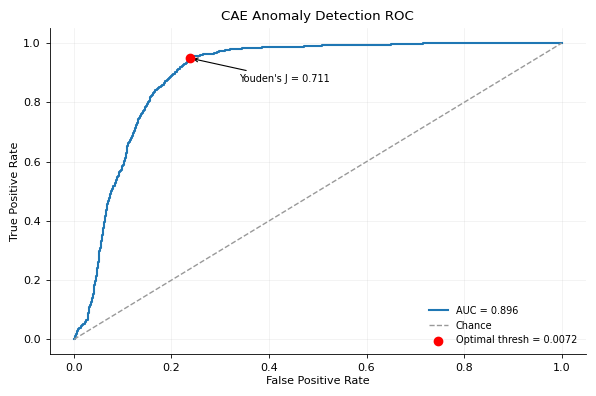

In [28]:
## VALIDATION ROC
recon = X_val_unhealthy.squeeze(1)
recon_errors_val = reconstruction_error(recon.cpu().numpy(), cae_val_unhealthy_rec)  # (N,)
y_true_val = y_val_unhealthy  # binary array
metrics = roc_analysis(y_true_val, recon_errors_val, pos_label=1)
fig, ax = plot_roc_clean(metrics, save_path="figure_roc_cae.pdf")

In [29]:

healthy_inds = np.where(y_true_val == 0)[0]
thrshold_percentage =0.90
threshold_unsupervised = np.quantile(recon_errors_val[healthy_inds], thrshold_percentage)  # 99th percentile
print(f"Unsupervised  = {threshold_unsupervised:.5f}")


Unsupervised  = 0.02514


In [30]:

anomaly_score_val = recon_errors_val
norm_anom_score_cae = (anomaly_score_val - np.min(anomaly_score_val)) / (np.max(anomaly_score_val) - np.min(anomaly_score_val))
binary_score_val = (anomaly_score_val >=  threshold_unsupervised).astype(int)


In [35]:

anomaly_score_cae = recon_errors
norm_anom_score_cae = (anomaly_score_cae - np.min(anomaly_score_cae)) / (np.max(anomaly_score_cae) - np.min(anomaly_score_cae))
binary_score_cae = (anomaly_score_cae >=  threshold_unsupervised).astype(int)


In [36]:

recon_errors_test = recon_errors
Nvox = R * H * W
anom_flat = np.zeros(Nvox, dtype=float)

split_t = len(tumor_idx_test)
anom_flat[tumor_idx_test]   = recon_errors_test[:split_t]
anom_flat[healthy_idx_test] = recon_errors_test[split_t:]
anom_img_3d  = anom_flat.reshape(R, H, W)
anom_img_cae = np.repeat(anom_img_3d[..., None], O, axis=-1)


In [37]:
anom_img_cae.shape

(3, 192, 192, 52)

In [38]:

print("anom_img_cae:", anom_img_cae.shape)
print ("nonzero voxels:", np.count_nonzero(anom_img_3d))


anom_img_cae: (3, 192, 192, 52)
nonzero voxels: 9320


In [39]:
# 1) Map scores back into the full voxel grid
idx_order = np.concatenate([tumor_idx_test, healthy_idx_test])

# 2) Allocate flat arrays over the full volume (R * H * W, O)
Nvox = R * H * W
flat_norm = np.zeros((Nvox, O), dtype=np.float32)
flat_bin  = np.zeros((Nvox, O), dtype=np.uint8)

# 3) Broadcast per-voxel scores across all offsets
norm_2d = np.repeat(norm_anom_score_cae[:, None], O, axis=1).astype(np.float32)  # (N_test, O)
bin_2d  = np.repeat(binary_score_cae[:,  None], O, axis=1).astype(np.uint8)      # (N_test, O)

flat_norm[idx_order] = norm_2d
flat_bin[idx_order]  = bin_2d

anom_norm_img_cae = flat_norm.reshape(R, H, W, O)  # continuous (normalized) anomaly map
bin_img_cae       = flat_bin.reshape(R, H, W, O)   # binary mask

anom_norm_img_cae[VAL_RAT_ID] = 0.0
bin_img_cae[VAL_RAT_ID]       = 0


In [40]:

print(f"anom_norm_img_cae: {anom_norm_img_cae.shape} | ")
print(f"nonzero offset 0: {(anom_norm_img_cae[..., 0] > 0).sum():d}")
print(f"bin_img_cae: {bin_img_cae.shape} | ")
print(f"positives offset 0: {bin_img_cae[..., 0].sum():d}")


anom_norm_img_cae: (3, 192, 192, 52) | 
nonzero offset 0: 9319
bin_img_cae: (3, 192, 192, 52) | 
positives offset 0: 1211


In [41]:
# plt.imshow(bin_img_cae[1,:,:,1])

In [42]:
# plt.imshow(anom_img_cae[0,:,:,1])

In [43]:
anomaly_score_cae.shape

(9320,)

### Generate Binary Mask 

$$
\mathrm{Dice}(A, B) = \dfrac{2\,|A \cap B|}{|A| + |B|}
$$


### Dice coefficient

In the tumor detection code, the Dice coefficient is computed per rat from the
model and ground-truth masks:

```python
a  = auto_mask[r]              # model (CAE) binary mask for rat r
t  = truth_mask[r]             # manual ground-truth mask for rat r
ov = np.logical_and(a, t)      # voxels where both are 1 (intersection)

dice = (2 * ov.sum()) / (a.sum() + t.sum()) 


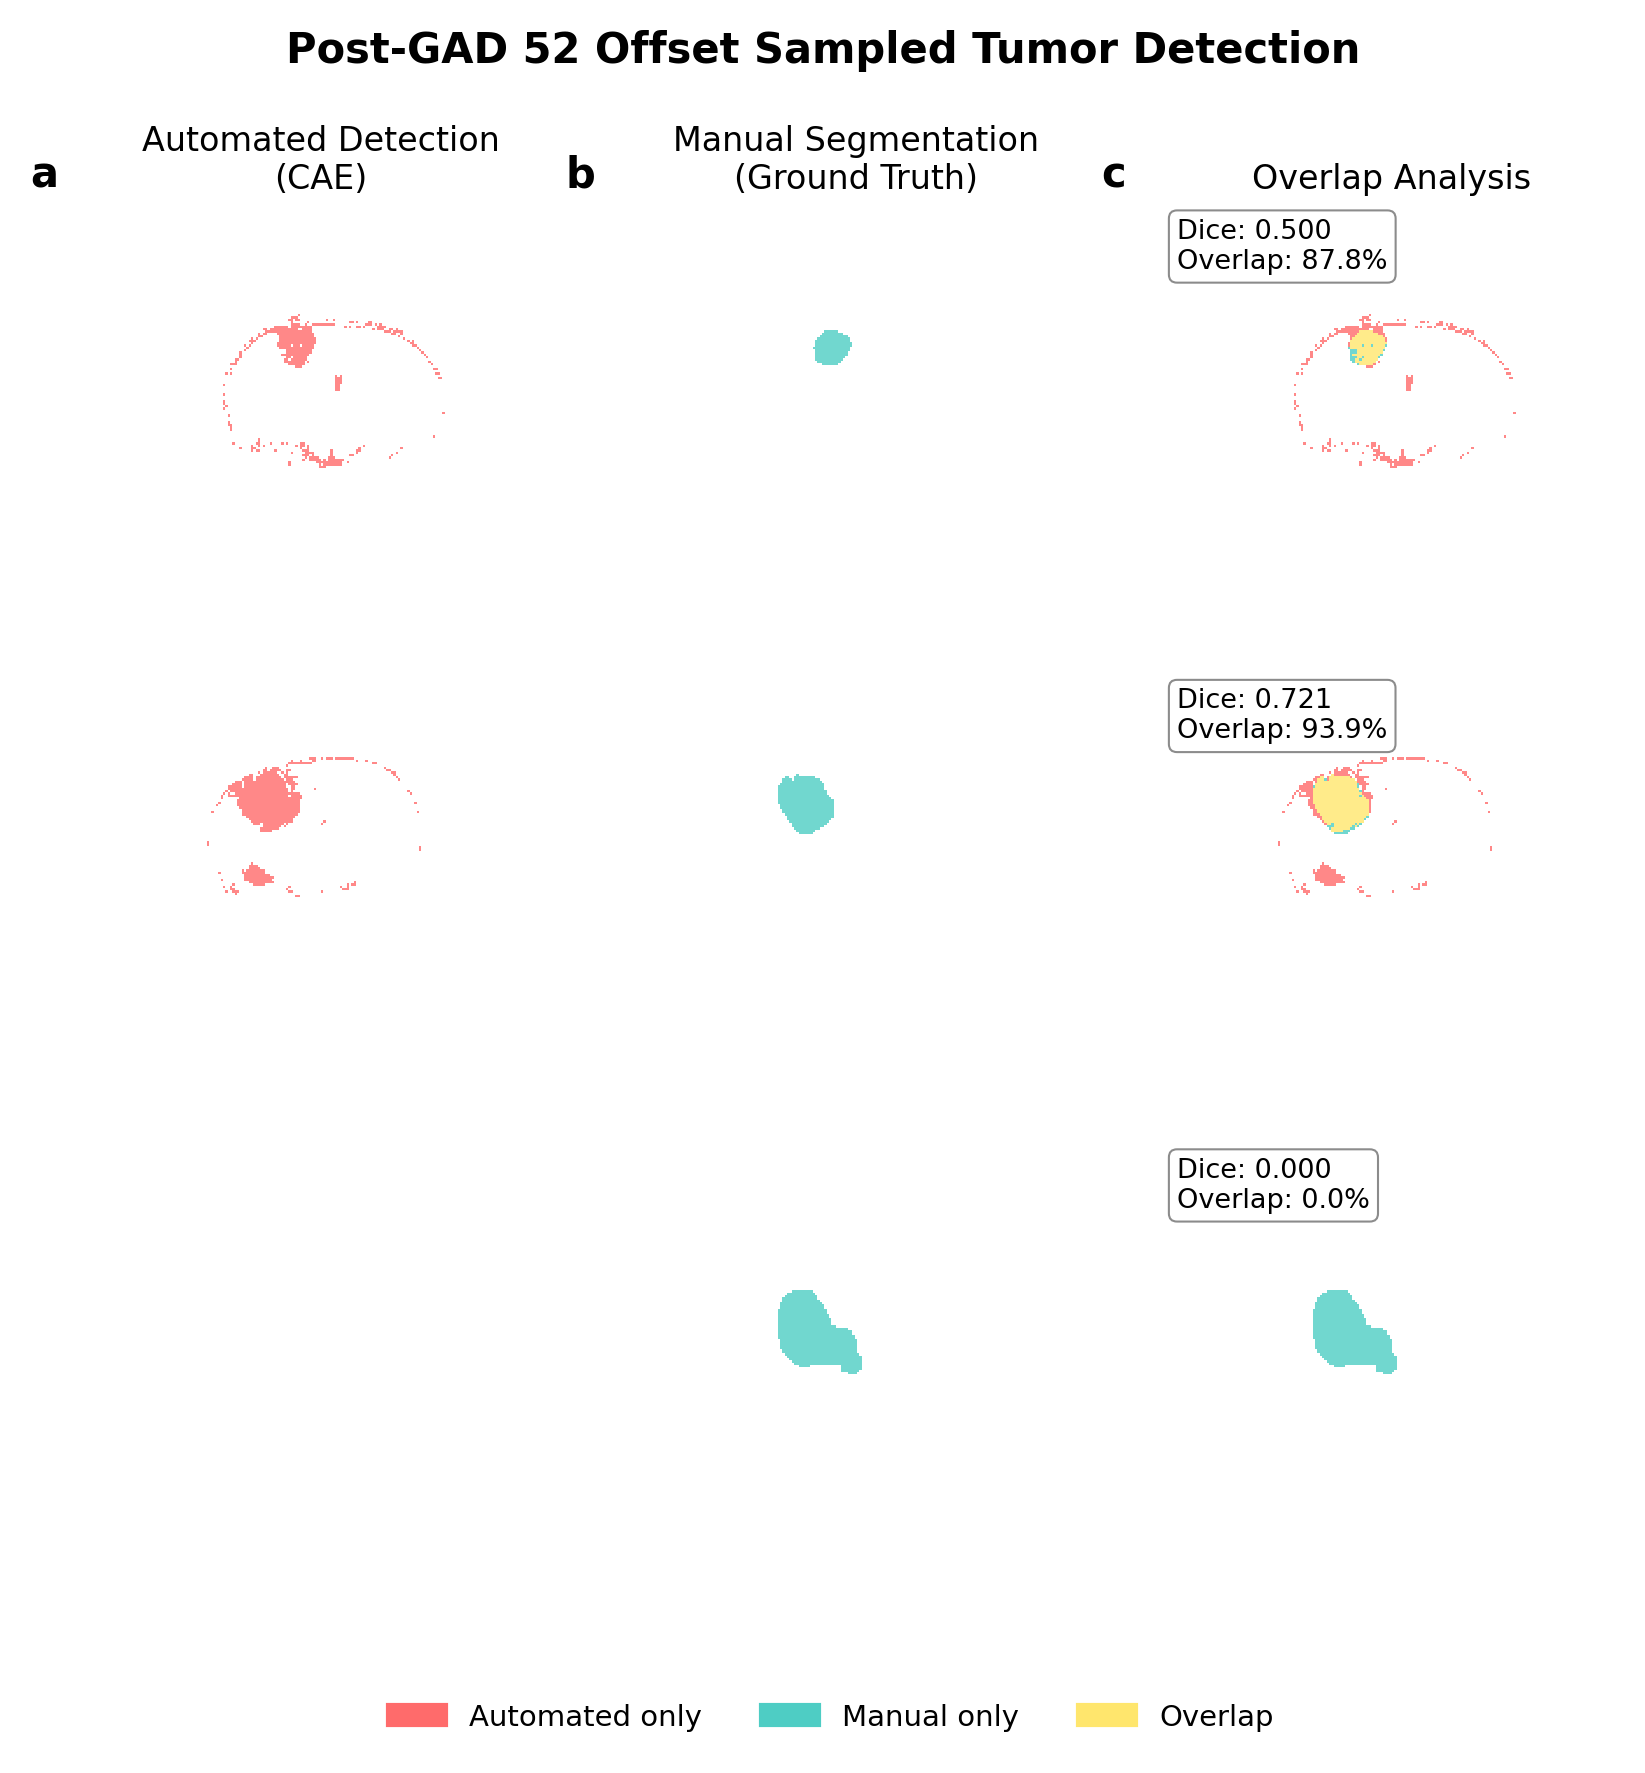

In [44]:
fig, axes = plot_tumor_detection(bin_img_cae, Tumor_Voxel_img, save_path="tumor_detection.png")

### Generate Anomaly Maks

In [45]:

def load_rotate_transpose(path):
    vols     = np.load(path)["data"]          # (5, 192, 192)
    vols_rot = np.rot90(vols, k=-1, axes=(1,2))
    arr      = np.transpose(vols_rot, (1,2,0))  # (192, 192, 5)
    return arr
SDF1 = load_rotate_transpose('data/sdf1.npz')
print("SDF1 shape:", SDF1.shape)
SDF4 = load_rotate_transpose('data/sdf4.npz')
print("SDF4 shape:", SDF4.shape)
CDF1 = load_rotate_transpose('data/cdf1.npz')
print("CDF1 shape:", CDF1.shape)
CDF3 = load_rotate_transpose('data/cdf3.npz')
CDF3 = CDF3.transpose(1,2,0)
print("CDF3 shape:", CDF3.shape)

SDF1 shape: (192, 192, 5)
SDF4 shape: (192, 192, 5)
CDF1 shape: (192, 192, 5)
CDF3 shape: (192, 192, 5)


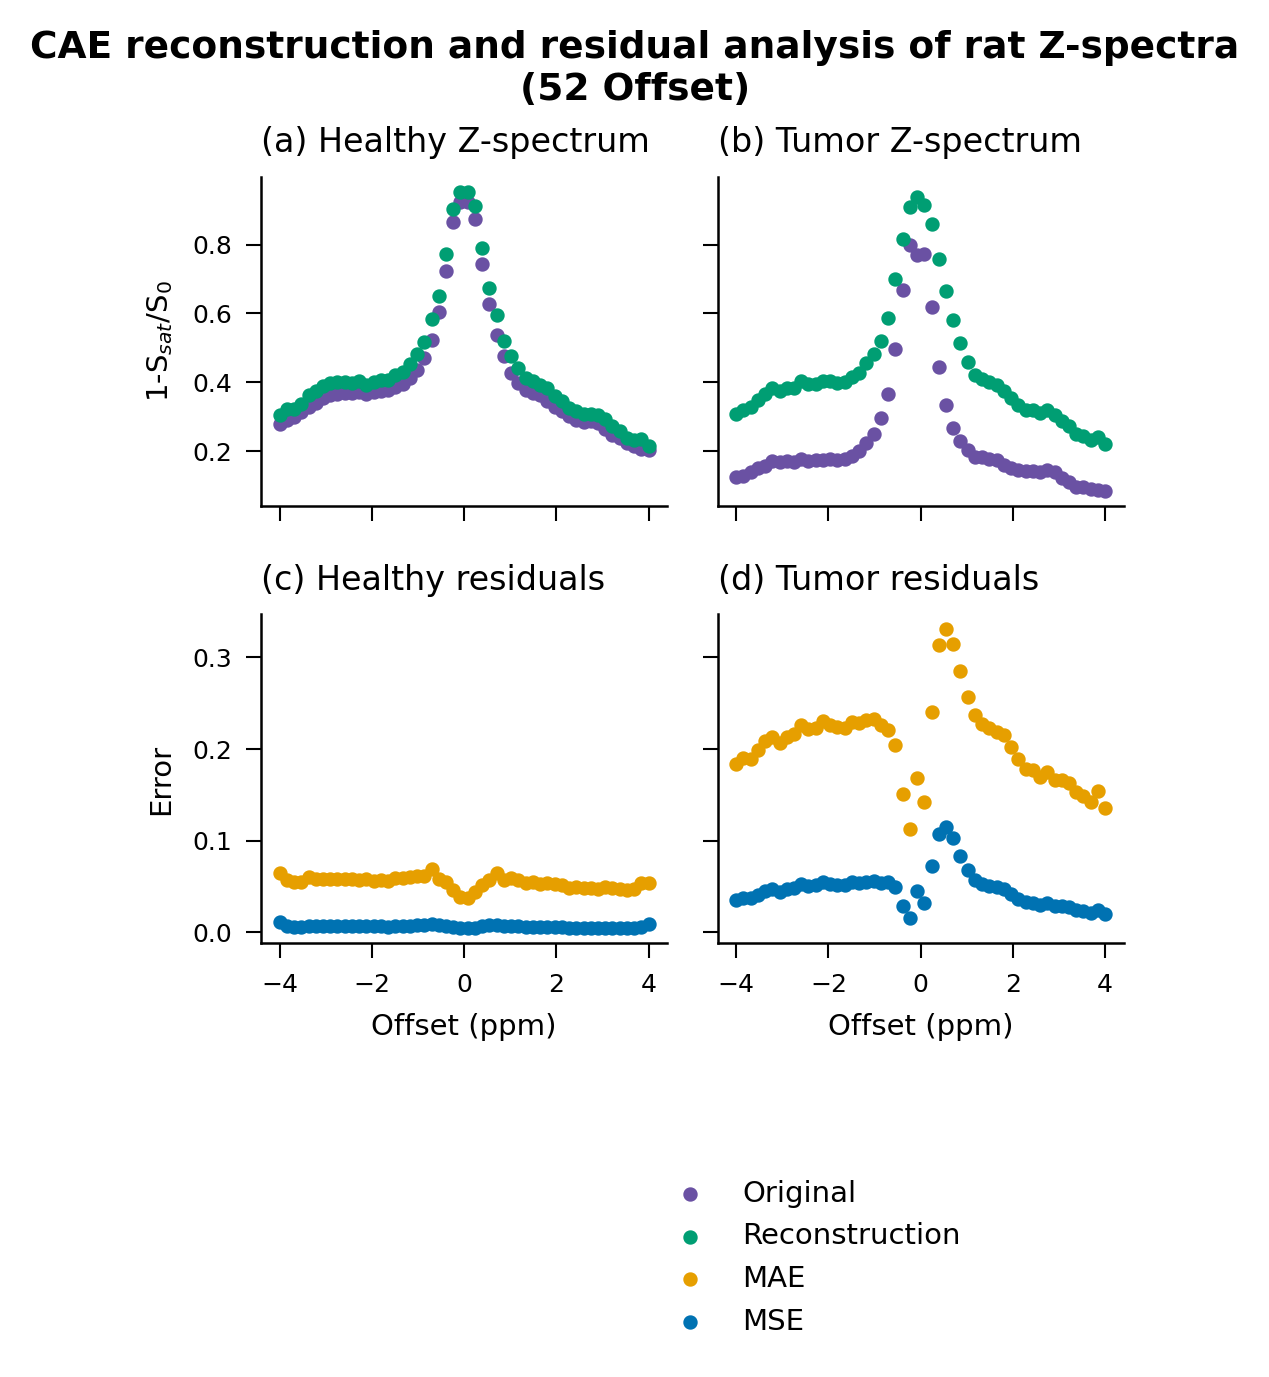

In [46]:
offset_axis = np.linspace(-4, 4, 52)
fig, axes = plot_zspec_recon_and_residuals_scatter(
    orig=X_test,                # (N,1,52) or (N,52) or torch.Tensor
    rec=cae_test_results,       # (N,52)
    y_true=rat_test_labels,     # (N,)
    offset_axis=offset_axis,
    save_path=None,             # e.g., "zspec_summary.pdf"
    show=True
)



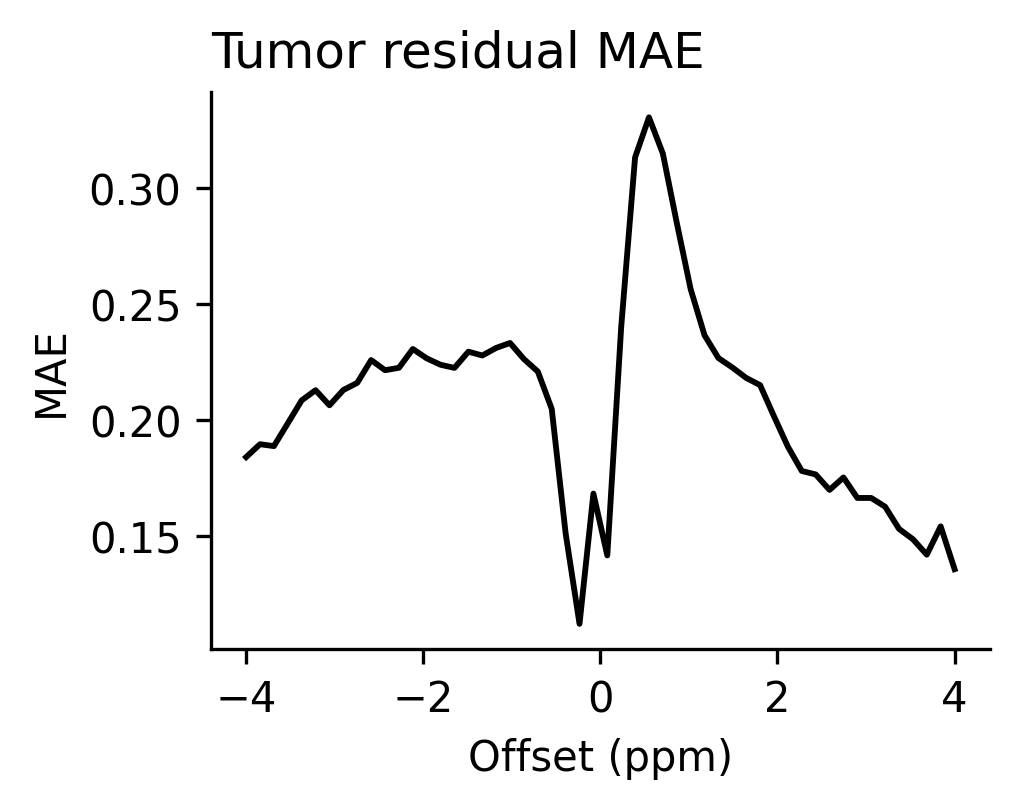

In [47]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')  
# --- originals & recons as (N, F) numpy ---
orig_np = X_test.squeeze(1).detach().cpu().numpy()      # (N, 52)
rec_np  = np.asarray(cae_test_results)                  # (N, 52)
y       = np.asarray(rat_test_labels).ravel()

# --- tumor only ---
tumor_inds = np.where(y == 1)[0]
o_t = orig_np[tumor_inds]
r_t = rec_np[tumor_inds]

# --- MAE per offset ---
mae = np.abs(o_t - r_t).mean(axis=0)

# --- offset axis ---
offset_axis = np.linspace(-4, 4, mae.shape[0])

# --- plot ---
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

ax.plot(offset_axis, mae, color="black", linewidth=1.4)

ax.set_title("Tumor residual MAE", loc="left")
ax.set_xlabel("Offset (ppm)")
ax.set_ylabel("MAE")

ax.set_xticks([-4, -2, 0, 2, 4])

# clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


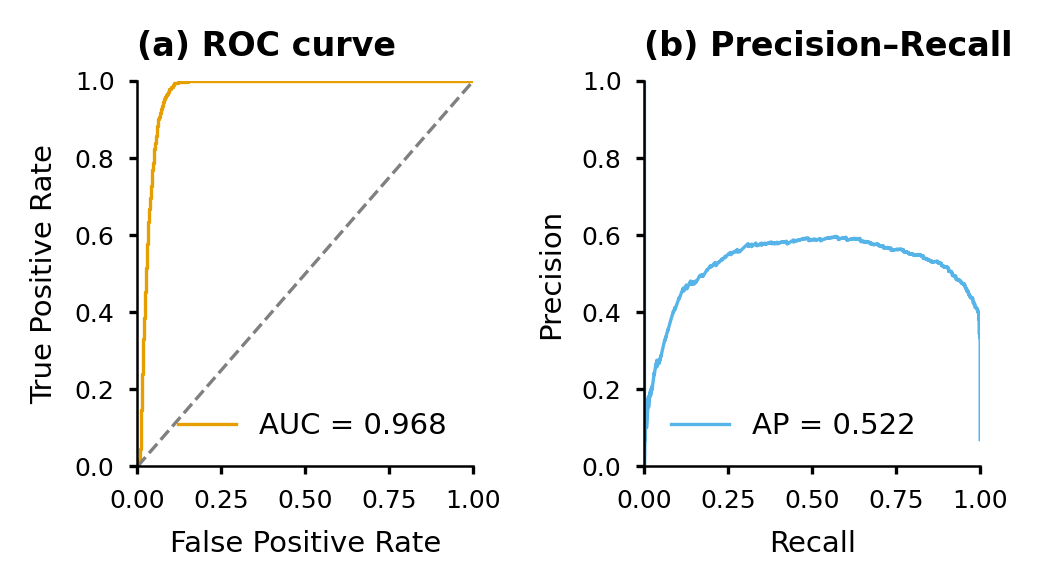

In [48]:
fig, axes = plot_roc_pr(y_true=rat_test_labels, scores=recon_errors,
                        pos_label=1, save_path=None, show=True)


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# Compute ROC
fpr1, tpr1, _ = roc_curve(rat_test_labels, recon_errors)
auc1 = roc_auc_score(rat_test_labels, recon_errors)

# Save ROC data
np.savez("roc52Offset_Optimal.npz", fpr=fpr1, tpr=tpr1, auc=auc1)

print("Saved ROC data to roc52Offset_Optimal.npz")


Saved ROC data to roc52Offset_Optimal.npz


In [50]:
nifti_image = nib.load('CDF1T1.nii')
cdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('SDF1T1.nii')
sdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('SDF4T1.nii')
sdf4_T1 = nifti_image.get_fdata()
#
cdf1_T1 = np.rot90(cdf1_T1[:, :, 5],k = 3)

sdf4_T1 = np.rot90(sdf4_T1[:, :, 4],k = 3)

sdf1_T1 = np.rot90(sdf1_T1[:, :, 6],k = 3)

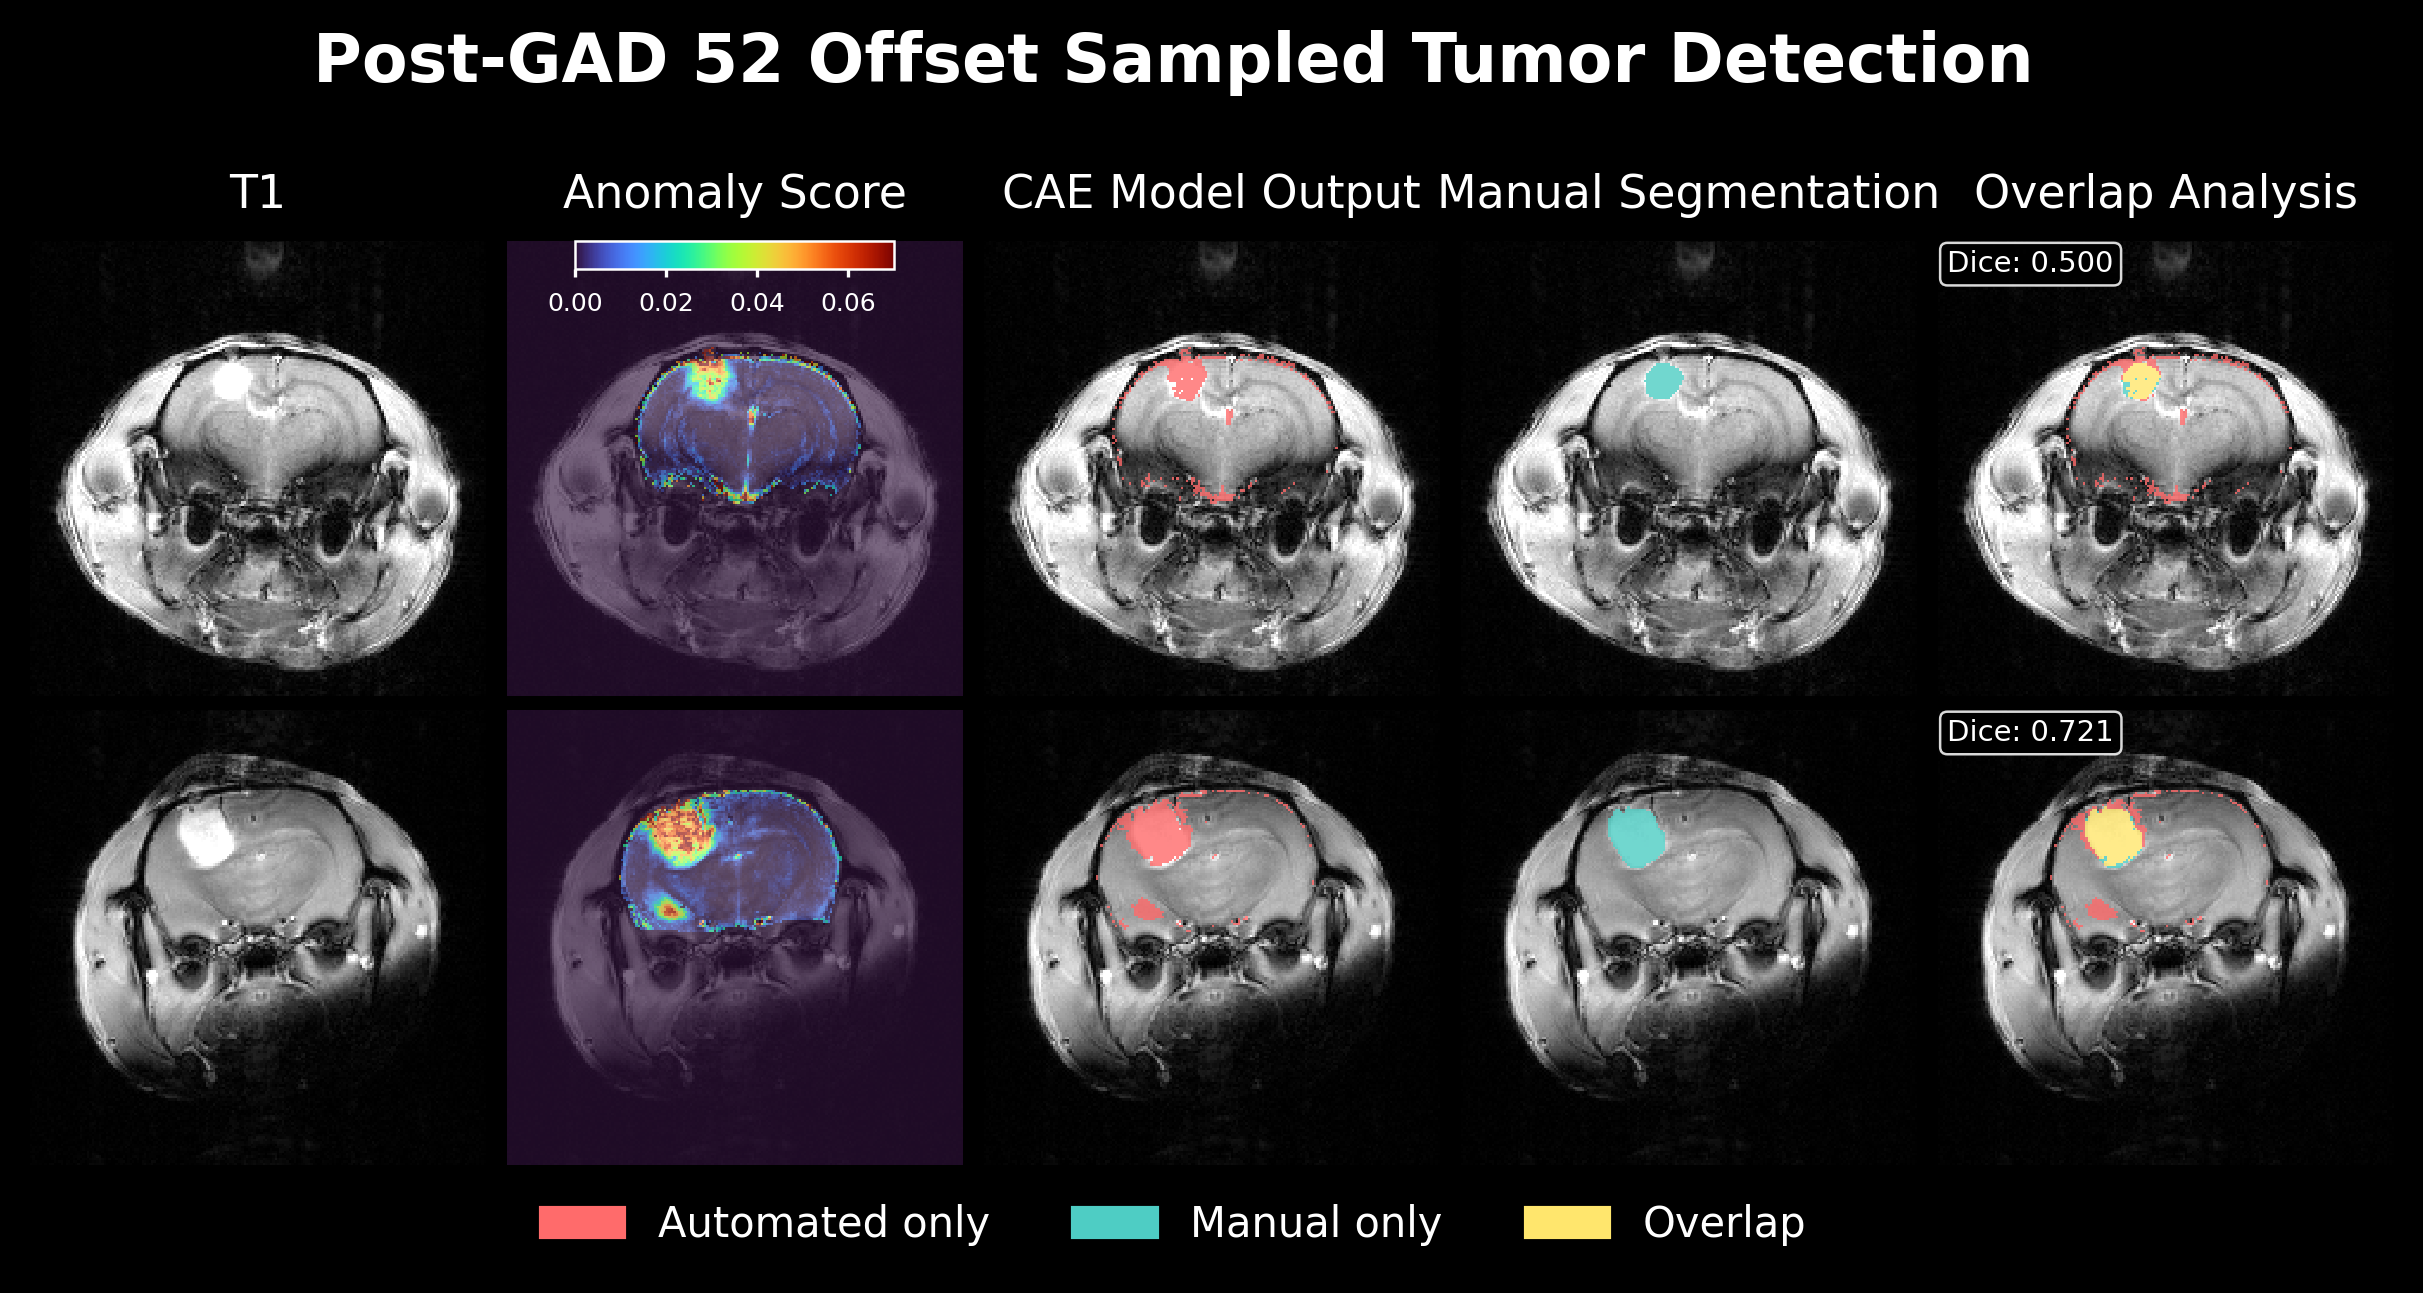

(<Figure size 3060x1320 with 11 Axes>,
 array([[<Axes: title={'center': 'T1'}>,
         <Axes: title={'center': 'Anomaly Score'}>,
         <Axes: title={'center': 'CAE Model Output'}>,
         <Axes: title={'center': 'Manual Segmentation'}>,
         <Axes: title={'center': 'Overlap Analysis'}>],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [51]:
plt.style.use('dark_background')  
t1_slices = (sdf4_T1, cdf1_T1, sdf1_T1)
auto2d  = bin_img_cae[..., 0].astype(bool)      # (3,H,W)
truth2d = Tumor_Voxel_img[..., 0].astype(bool)  # (3,H,W)

anom_3xHW = np.stack([
    anom_img_cae[0, ..., 0],
    anom_img_cae[1, ..., 0],
    anom_img_cae[2, ..., 0],
], axis=0)

plot_masks_over_t1_slices(
    t1_slices,
    auto2d,
    truth2d,
    anom_maps=anom_3xHW,
    anom_cmap='turbo',
    anom_alpha=0.65,
    offset_number=52,
    save_path="tumor_detection_with_blankT1.png"
)


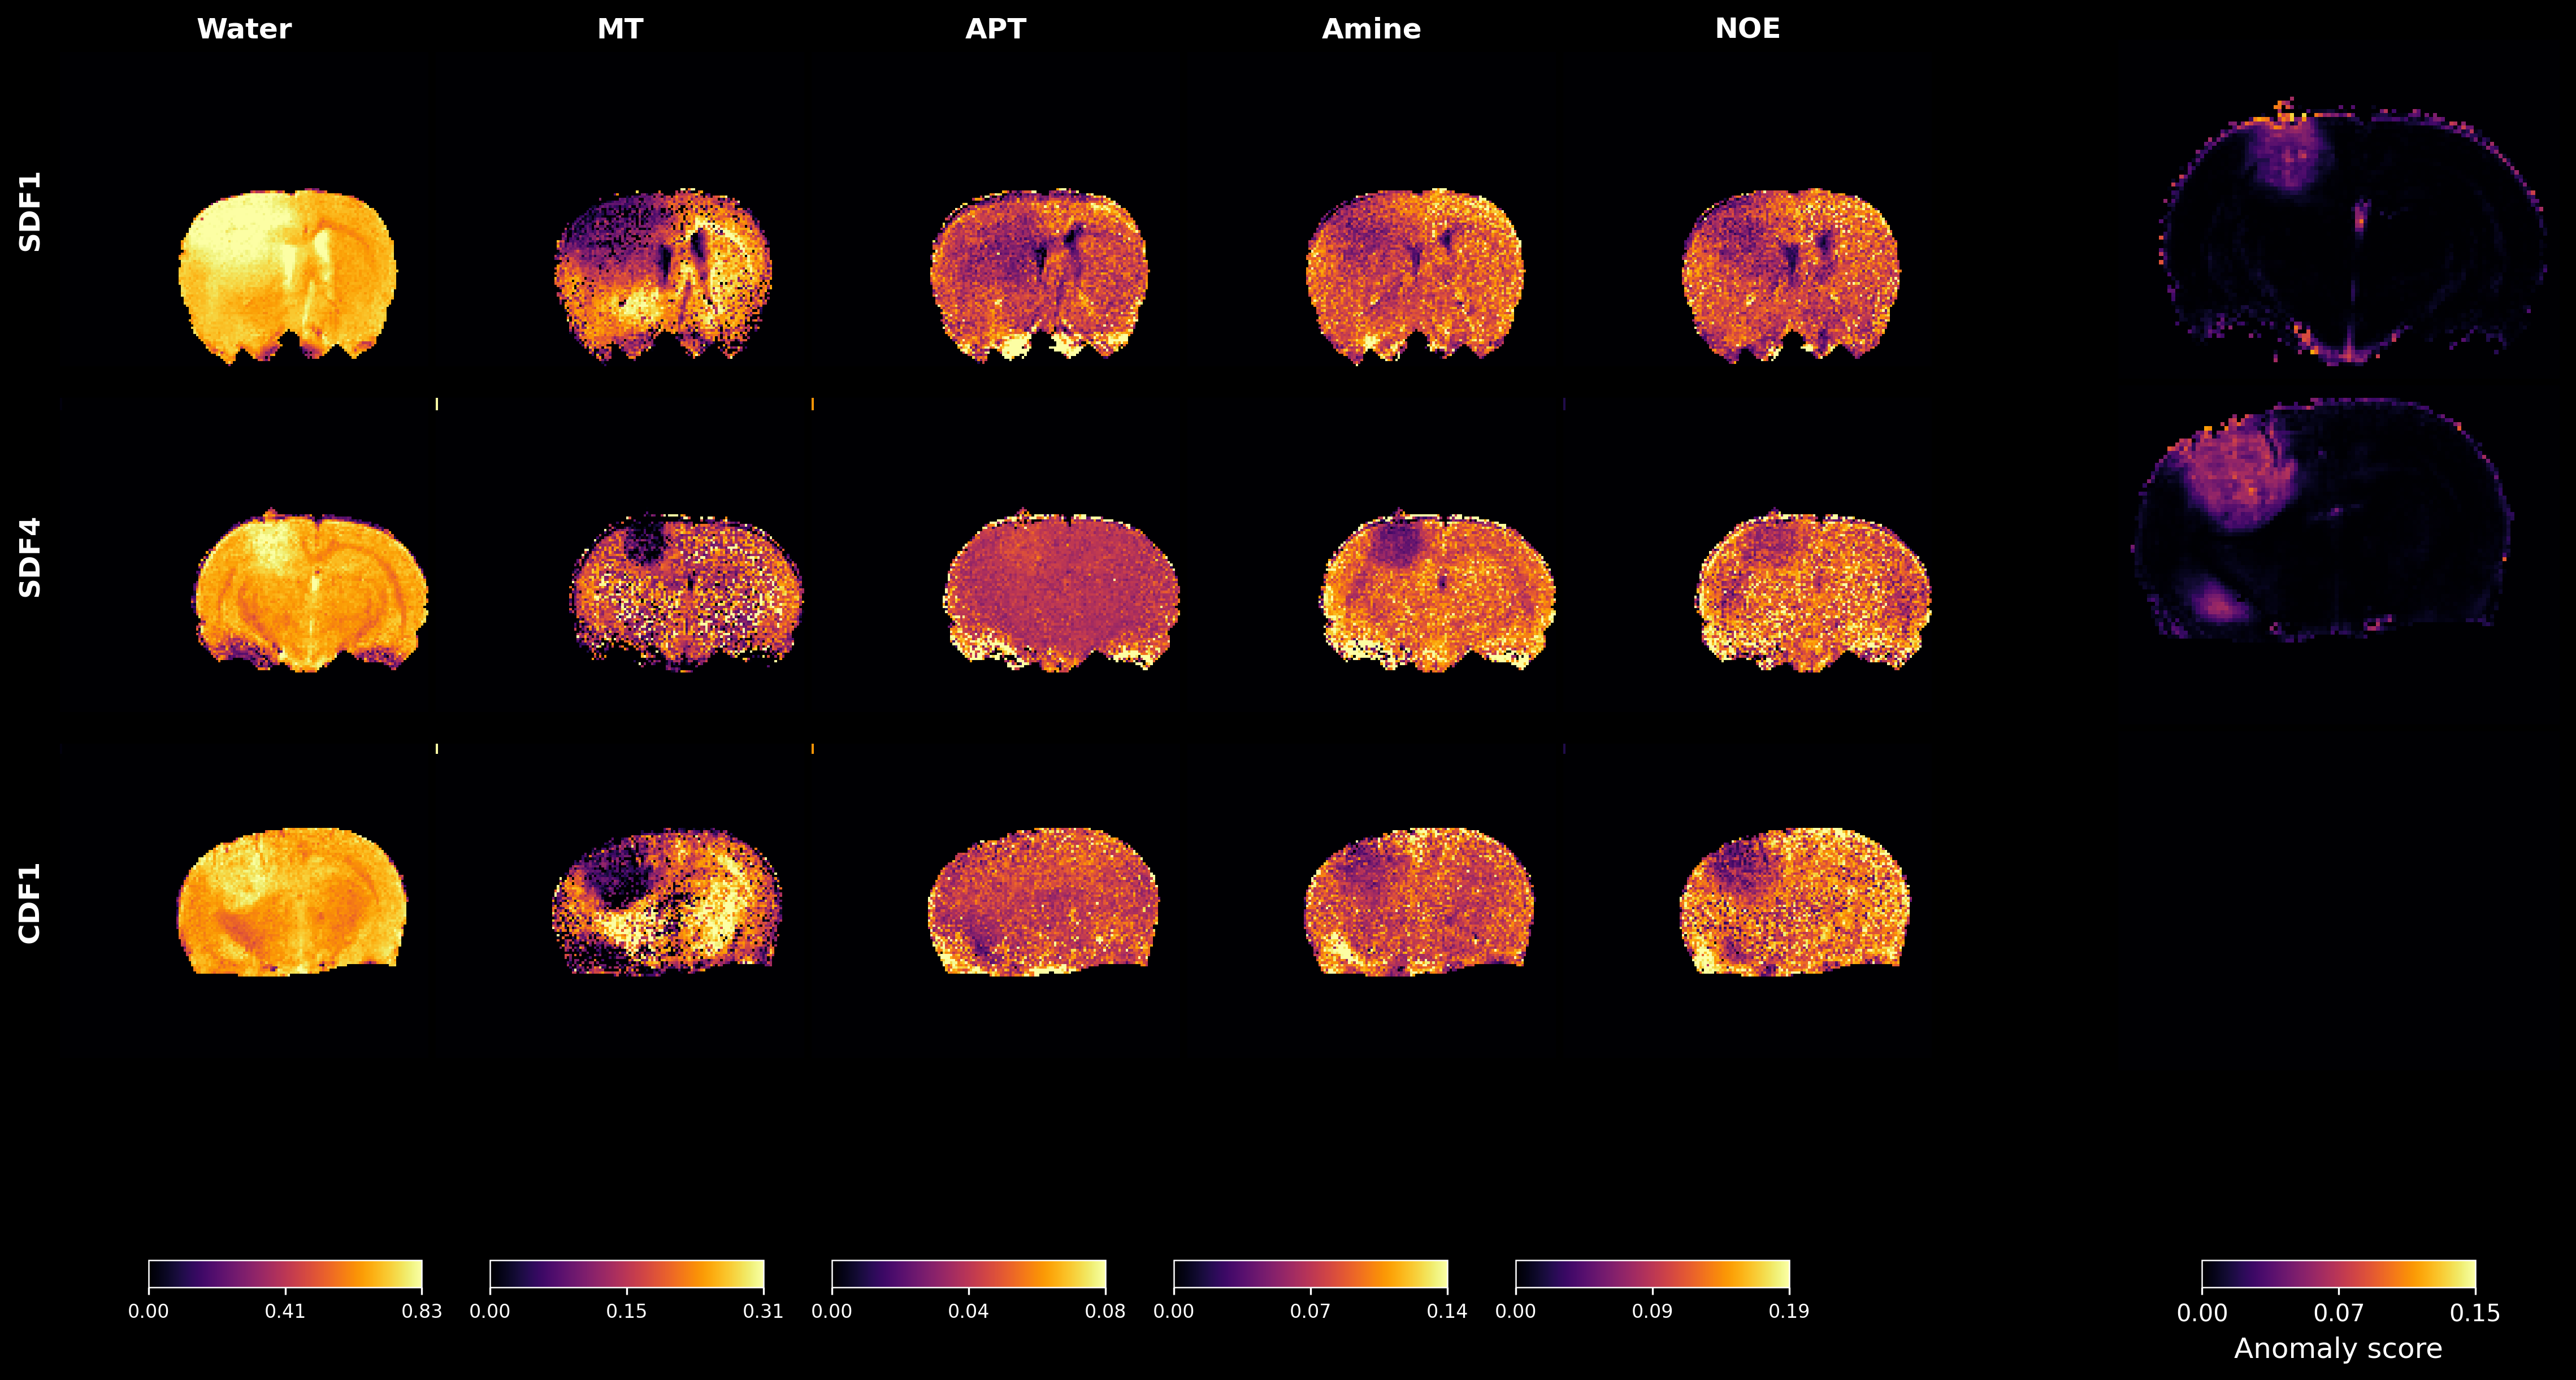

In [52]:
plt.style.use('dark_background') 
fig = plot_combined_grid_and_anomaly(SDF1, SDF4, CDF1, anom_img_cae)


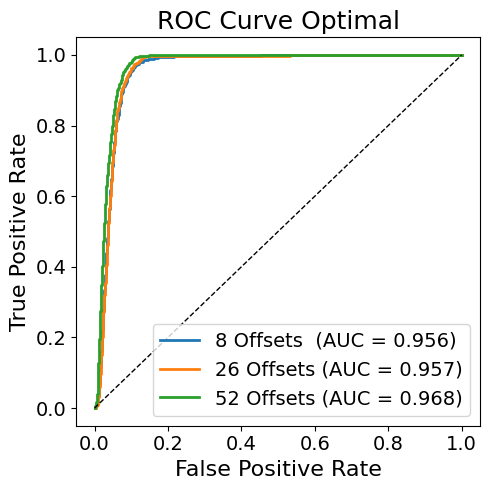

In [53]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default') 
# Load saved files
roc8  = np.load("roc8Offset_Optimal.npz")
roc26 = np.load("roc26Offset_Optimal.npz")
roc52 = np.load("roc52Offset_Optimal.npz")

fpr8,  tpr8,  auc8  = roc8["fpr"],  roc8["tpr"],  float(roc8["auc"])
fpr26, tpr26, auc26 = roc26["fpr"], roc26["tpr"], float(roc26["auc"])
fpr52, tpr52, auc52 = roc52["fpr"], roc52["tpr"], float(roc52["auc"])

plt.figure(figsize=(5, 5))

plt.plot(fpr8,  tpr8,  label=f"8 Offsets  (AUC = {auc8:.3f})",  linewidth=2)
plt.plot(fpr26, tpr26, label=f"26 Offsets (AUC = {auc26:.3f})", linewidth=2)
plt.plot(fpr52, tpr52, label=f"52 Offsets (AUC = {auc52:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("ROC Curve Optimal", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, frameon=True)

plt.tight_layout()
plt.show()


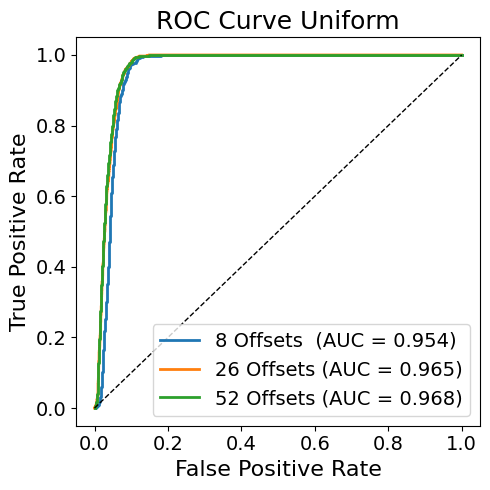

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved files
roc8  = np.load("roc8Offset_Uniform.npz")
roc26 = np.load("roc26Offset_Uniform.npz")
roc52 = np.load("roc52Offset_Optimal.npz")

fpr8,  tpr8,  auc8  = roc8["fpr"],  roc8["tpr"],  float(roc8["auc"])
fpr26, tpr26, auc26 = roc26["fpr"], roc26["tpr"], float(roc26["auc"])
fpr52, tpr52, auc52 = roc52["fpr"], roc52["tpr"], float(roc52["auc"])

plt.figure(figsize=(5, 5))

plt.plot(fpr8,  tpr8,  label=f"8 Offsets  (AUC = {auc8:.3f})",  linewidth=2)
plt.plot(fpr26, tpr26, label=f"26 Offsets (AUC = {auc26:.3f})", linewidth=2)
plt.plot(fpr52, tpr52, label=f"52 Offsets (AUC = {auc52:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("ROC Curve Uniform", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, frameon=True)

plt.tight_layout()
plt.show()


In [55]:
import numpy as np
import pandas as pd
import glob
import os

# Folder containing all metric files
metric_files = sorted(glob.glob("./metrics/metrics_*.npz"))

rows = []

for file in metric_files:
    data = np.load(file)

    # extract model name from filename
    name = os.path.basename(file).replace("metrics_", "").replace(".npz", "")

    # build row from available fields
    rows.append({
        "Model": name,
        "Accuracy": float(data["accuracy"]),
        "F1": float(data["f1"]),
        "ROC AUC": float(data["roc_auc"]),
        "PR AUC": float(data["pr_auc"]),
        "Precision": float(data["precision"]),
        "Recall": float(data["recall"]),
        "Threshold": float(data["threshold"]),
    })

# Create DataFrame
df = pd.DataFrame(rows)

# Sort nicely: 8 → 26 → 52 and Uniform → Optimal
df = df.sort_values("Model")

# Round for display
df_rounded = df.round(4)

df_rounded


,Model,Accuracy,F1,ROC AUC,PR AUC,Precision,Recall,Threshold
0,26Offset_Optimal,0.9246,0.6206,0.9568,0.4425,0.4772,0.8873,0.0229
1,26Offset_Uniform,0.9260,0.6349,0.9655,0.5046,0.4831,0.9259,0.0235
2,8Offset_Optimal,0.9250,0.6202,0.9564,0.4446,0.4790,0.8796,0.0092
3,8Offset_Uniform,0.9182,0.6120,0.9542,0.4147,0.4567,0.9275,0.0161


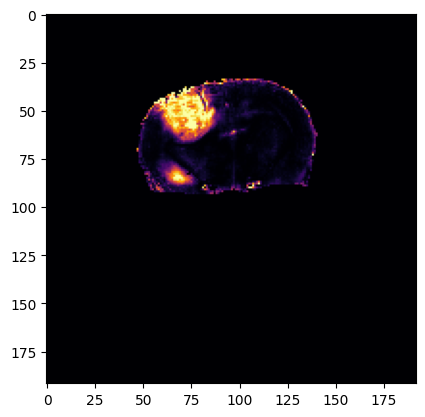

In [56]:
plt.imshow(anom_img_cae[0,:,:,0], vmin = 0, vmax = 0.06, cmap = "inferno")
plt.imshow(anom_img_cae[1,:,:,0], vmin = 0, vmax = 0.06, cmap = "inferno")

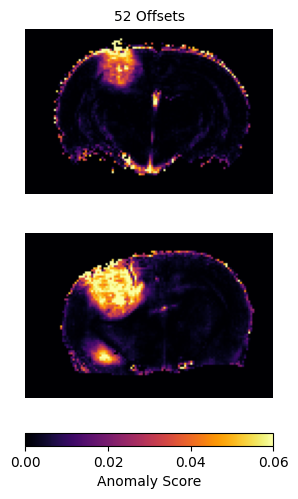

In [57]:
# Define your crop windows
crop_left  = (slice(40,120), slice(40,160))   # Rat 1
crop_right = (slice(25,105), slice(30,150))   # Rat 2

fig, ax = plt.subplots(2, 1, figsize=(3.2, 6))  # 2 rows, 1 column

# Adjust vertical spacing
fig.subplots_adjust(top=0.85, bottom=0.12, hspace=0.15)

# --- Rat 1 (top) ---
im0 = ax[0].imshow(
    anom_img_cae[0][crop_left + (slice(0,1),)],
    vmin=0, vmax=0.06, cmap="inferno"
)
ax[0].set_title("52 Offsets", fontsize=10)
ax[0].set_aspect("equal")
ax[0].axis("off")

# --- Rat 2 (bottom) ---
im1 = ax[1].imshow(
    anom_img_cae[1][crop_right + (slice(0,1),)],
    vmin=0, vmax=0.06, cmap="inferno"
)
ax[1].set_title("", fontsize=10)
ax[1].set_aspect("equal")
ax[1].axis("off")

# Shared horizontal colorbar BELOW both images
cbar = fig.colorbar(
    im1, ax=ax.ravel().tolist(), orientation="horizontal",
    fraction=0.05, pad=0.08
)
cbar.set_label("Anomaly Score", fontsize=10)

plt.show()


In [58]:

# --- 1) Prep data ---
orig = np.asarray(X_test).squeeze()        # (N, 52) from torch.Tensor or np
rec  = np.asarray(cae_test_results)       # (N, 52)
y    = np.asarray(rat_test_labels)        # (N,)

# CAE anomaly score = MAE per voxel
scores = np.mean((orig - rec)**2, axis=1)

# --- 2) Metrics ---
# ROC / AUC
fpr, tpr, thr = roc_curve(y, scores)
roc_auc = roc_auc_score(y, scores)

# PR / AUC
prec_arr, rec_arr, _ = precision_recall_curve(y, scores)
pr_auc = average_precision_score(y, scores)

# best threshold via Youden's J
j = tpr - fpr
best_thr =  threshold_unsupervised


y_pred = (scores >= best_thr).astype(int)

acc  = accuracy_score(y, y_pred)
f1   = f1_score(y, y_pred)
prec = precision_score(y, y_pred)
rec_ = recall_score(y, y_pred)

# --- 3) One-row DataFrame for CAE ---
df_cae = pd.DataFrame([{
    "Model": "CAE",
    "Accuracy": acc,
    "F1": f1,
    "ROC AUC": roc_auc,
    "PR AUC": pr_auc,
    "Precision": prec,
    "Recall": rec_,
    "Dice 1": None,   # fill in if you have it
    "Dice 2": None,   # fill in if you have it
}]).round(3)

df_cae



,Model,Accuracy,F1,ROC AUC,PR AUC,Precision,Recall,Dice 1,Dice 2
0,CAE,0.929,0.642,0.968,0.522,0.493,0.921,None,None
